In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [262]:
fuel = pd.read_csv(r"data\fuel.csv")
fuel

,fuel,emissions_tons_per_kwh
0,petrol,0.25
1,diesel,0.35


In [263]:
vehicles = pd.read_csv(r"data\vehicles.csv")
vehicles

,vehicle,power_kwh,fuel
0,tractor,9000,diesel
1,lawnmower,450,petrol
2,generator,1100,petrol
3,generator,2300,diesel


In [264]:
df = fuel.merge(vehicles,"inner","fuel")
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh
0,petrol,0.25,lawnmower,450
1,petrol,0.25,generator,1100
2,diesel,0.35,tractor,9000
3,diesel,0.35,generator,2300


In [265]:
years = np.arange(2026,2030,1)
years

array([2026, 2027, 2028, 2029])

In [266]:
def calc_carbon_cost(year):
    cost = 50 + ((year-2026)**0.6)
    return cost

In [267]:
carbon_costs = calc_carbon_cost(years)
carbon_costs

array([50.        , 51.        , 51.51571657, 51.93318204])

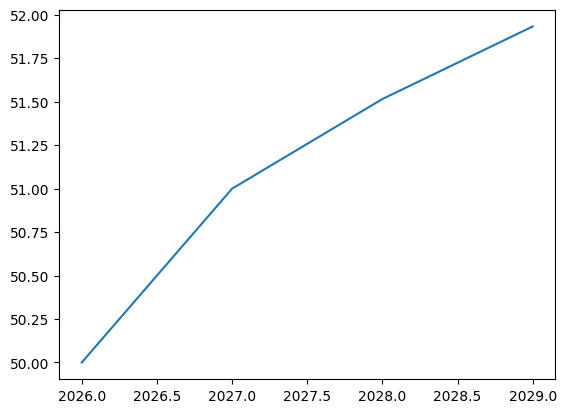

In [268]:
plt.plot(years, carbon_costs)

In [269]:
carbon_costs_table = pd.DataFrame({'year':years, 'offset_base_cost_gbp_per_ton':carbon_costs})
carbon_costs_table

,year,offset_base_cost_gbp_per_ton
0,2026,50.000000
1,2027,51.000000
2,2028,51.515717
3,2029,51.933182


In [270]:
df = df.merge(carbon_costs_table,"cross")
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh,year,offset_base_cost_gbp_per_ton
0,petrol,0.25,lawnmower,450,2026,50.000000
1,petrol,0.25,lawnmower,450,2027,51.000000
2,petrol,0.25,lawnmower,450,2028,51.515717
3,petrol,0.25,lawnmower,450,2029,51.933182
4,petrol,0.25,generator,1100,2026,50.000000
5,petrol,0.25,generator,1100,2027,51.000000
6,petrol,0.25,generator,1100,2028,51.515717
7,petrol,0.25,generator,1100,2029,51.933182
8,diesel,0.35,tractor,9000,2026,50.000000
9,diesel,0.35,tractor,9000,2027,51.000000


In [272]:
df["emissions_tons_per_year"] = df["emissions_tons_per_kwh"] * df["power_kwh"]
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh,year,offset_base_cost_gbp_per_ton,emissions_tons_per_year
0,petrol,0.25,lawnmower,450,2026,50.000000,112.5
1,petrol,0.25,lawnmower,450,2027,51.000000,112.5
2,petrol,0.25,lawnmower,450,2028,51.515717,112.5
3,petrol,0.25,lawnmower,450,2029,51.933182,112.5
4,petrol,0.25,generator,1100,2026,50.000000,275.0
5,petrol,0.25,generator,1100,2027,51.000000,275.0
6,petrol,0.25,generator,1100,2028,51.515717,275.0
7,petrol,0.25,generator,1100,2029,51.933182,275.0
8,diesel,0.35,tractor,9000,2026,50.000000,3150.0
9,diesel,0.35,tractor,9000,2027,51.000000,3150.0


In [273]:
df["offset_cost_gbp_per_year"] = df["offset_base_cost_gbp_per_ton"] * df["emissions_tons_per_year"]
df

,fuel,emissions_tons_per_kwh,vehicle,power_kwh,year,offset_base_cost_gbp_per_ton,emissions_tons_per_year,offset_cost_gbp_per_year
0,petrol,0.25,lawnmower,450,2026,50.000000,112.5,5625.000000
1,petrol,0.25,lawnmower,450,2027,51.000000,112.5,5737.500000
2,petrol,0.25,lawnmower,450,2028,51.515717,112.5,5795.518114
3,petrol,0.25,lawnmower,450,2029,51.933182,112.5,5842.482980
4,petrol,0.25,generator,1100,2026,50.000000,275.0,13750.000000
5,petrol,0.25,generator,1100,2027,51.000000,275.0,14025.000000
6,petrol,0.25,generator,1100,2028,51.515717,275.0,14166.822056
7,petrol,0.25,generator,1100,2029,51.933182,275.0,14281.625062
8,diesel,0.35,tractor,9000,2026,50.000000,3150.0,157500.000000
9,diesel,0.35,tractor,9000,2027,51.000000,3150.0,160650.000000


say now we want to anaylise the cost per year, this is a quite complex query

In [280]:
year_projection = df.groupby('year').sum()
year_projection

,fuel,emissions_tons_per_kwh,vehicle,power_kwh,offset_base_cost_gbp_per_ton,emissions_tons_per_year,offset_cost_gbp_per_year
year,,,,,,,
2026,petrolpetroldieseldiesel,1.2,lawnmowergeneratortractorgenerator,12850,200.000000,4342.5,217125.00000
2027,petrolpetroldieseldiesel,1.2,lawnmowergeneratortractorgenerator,12850,204.000000,4342.5,221467.50000
2028,petrolpetroldieseldiesel,1.2,lawnmowergeneratortractorgenerator,12850,206.062866,4342.5,223706.99919
2029,petrolpetroldieseldiesel,1.2,lawnmowergeneratortractorgenerator,12850,207.732728,4342.5,225519.84303


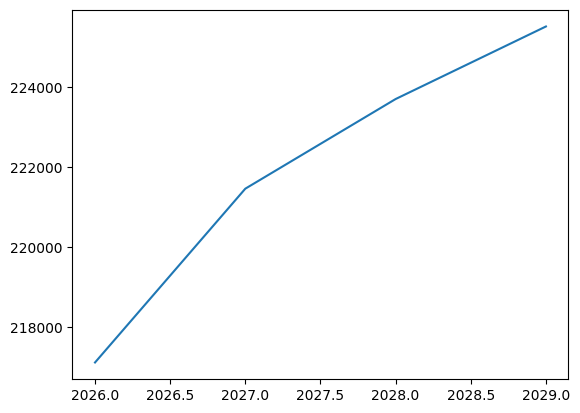

In [285]:
plt.plot(year_projection['offset_cost_gbp_per_year'])

In [286]:
df = df.set_index(["year", "vehicle", "fuel"]).sort_index()
df

emissions_tons_per_kwh  power_kwh  \
year vehicle   fuel                                        
2026 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2027 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2028 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   
2029 generator diesel                    0.35       2300   
               petrol                    0.25       1100   
     lawnmower petrol                    0.25        450   
     tractor   diesel                    0.35       9000   

                       offset_base_cost_gbp_per_ton  emissions_tons_per_year  \
year vehicle   fuel                                                            
2026 generator diesel                     50.000000                    805.0   
               petrol                     50.000000                    275.0   
     lawnmower petrol                     50.000000                    112.5   
     tractor   diesel                     50.000000                   3150.0   
2027 generator diesel                     51.000000                    805.0   
               petrol                     51.000000                    275.0   
     lawnmower petrol                     51.000000                    112.5   
     tractor   diesel                     51.000000                   3150.0   
2028 generator diesel                     51.515717                    805.0   
               petrol                     51.515717                    275.0   
     lawnmower petrol                     51.515717                    112.5   
     tractor   diesel                     51.515717                   3150.0   
2029 generator diesel                     51.933182                    805.0   
               petrol                     51.933182                    275.0   
     lawnmower petrol                     51.933182                    112.5   
     tractor   diesel                     51.933182                   3150.0   

                       offset_cost_gbp_per_year  
year vehicle   fuel                              
2026 generator diesel              40250.000000  
               petrol              13750.000000  
     lawnmower petrol               5625.000000  
     tractor   diesel             157500.000000  
2027 generator diesel              41055.000000  
               petrol              14025.000000  
     lawnmower petrol               5737.500000  
     tractor   diesel             160650.000000  
2028 generator diesel              41470.151836  
               petrol              14166.822056  
     lawnmower petrol               5795.518114  
     tractor   diesel             162274.507185  
2029 generator diesel              41806.211546  
               petrol              14281.625062  
     lawnmower petrol               5842.482980  
     tractor   diesel             163589.523442

In [287]:
year_projection = df.groupby('year').sum()
year_projection

,emissions_tons_per_kwh,power_kwh,offset_base_cost_gbp_per_ton,emissions_tons_per_year,offset_cost_gbp_per_year
year,,,,,
2026,1.2,12850,200.000000,4342.5,217125.00000
2027,1.2,12850,204.000000,4342.5,221467.50000
2028,1.2,12850,206.062866,4342.5,223706.99919
2029,1.2,12850,207.732728,4342.5,225519.84303


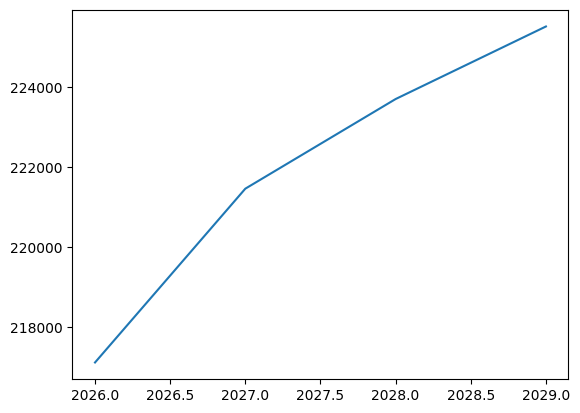

In [288]:
plt.plot(year_projection['offset_cost_gbp_per_year'])